In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.utils import resample
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

/Utilisateurs/amudet01/.cache/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-dhwi5xcb because there was an issue with the default path (/Utilisateurs/amudet01/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [19]:
summary_files = glob("embedding_benchmark_results/*/summary.csv")

In [20]:
df_list = [pd.read_csv(file) for file in summary_files]
df_summary = pd.concat(df_list, ignore_index=True)
df_summary

,Model,Mean Top-1 Similarity,Mean Top-5 Similarity,Mean Drop Top-1 to Top-2,Doc Encoding Time (s),Embedding Dimension,Corpus Languages
0,all-MiniLM-L6-v2,1.0,0.7222,0.3087,72.91,384,"['en', 'fr']"
1,e5-small-v2,1.0,0.9073,0.1050,125.20,384,"['en', 'fr']"
2,multilingual-e5-large-instruct,1.0,0.9134,0.0972,360.63,1024,"['en', 'fr']"
3,linq-embed-mistral,1.0,0.7410,0.2918,6184.69,4096,"['en', 'fr']"
4,SFR-Embedding-Mistral,1.0,0.8123,0.2090,6143.25,4096,"['en', 'fr']"


In [6]:
model_dir = f"embedding_benchmark_results/*"

In [7]:
sim_files = sorted(glob(os.path.join(model_dir, "similarities_step_*.npy")),
                   key=lambda x: int(os.path.basename(x).split("_")[-1].split(".")[0]))
idx_files = sorted(glob(os.path.join(model_dir, "indices_step_*.npy")),
                   key=lambda x: int(os.path.basename(x).split("_")[-1].split(".")[0]))

In [8]:
D_all = np.vstack([np.load(f) for f in sim_files])
I_all = np.vstack([np.load(f) for f in idx_files])

In [9]:
top1 = D_all[:, 0]
top5_mean = D_all[:, :5].mean(axis=1)
drop_1_2 = D_all[:, 0] - D_all[:, 1]

/tmp/ipykernel_1966565/3674331288.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Utilisateurs/amudet01/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


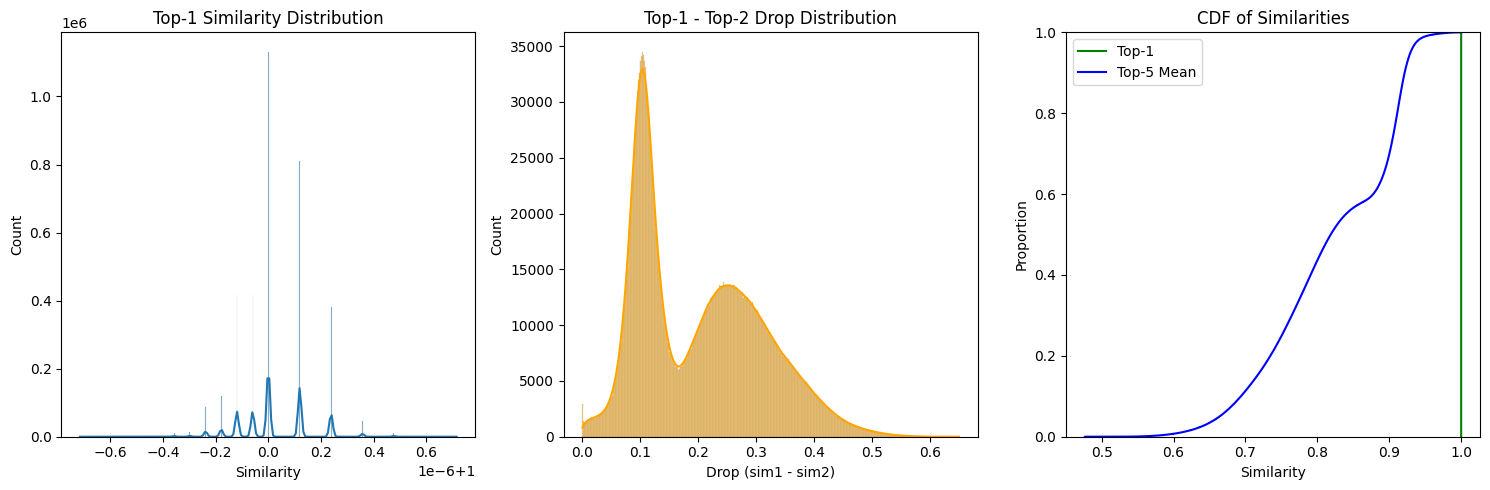

In [10]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(top1, bins=500, kde=True)
plt.title("Top-1 Similarity Distribution")
plt.xlabel("Similarity")
plt.ylabel("Count")

plt.subplot(1, 3, 2)
sns.histplot(drop_1_2, bins=500, kde=True, color="orange")
plt.title("Top-1 - Top-2 Drop Distribution")
plt.xlabel("Drop (sim1 - sim2)")
plt.ylabel("Count")

plt.subplot(1, 3, 3)
sns.ecdfplot(top1, label="Top-1", color="green")
sns.ecdfplot(top5_mean, label="Top-5 Mean", color="blue")
plt.title("CDF of Similarities")
plt.xlabel("Similarity")
plt.legend()

plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

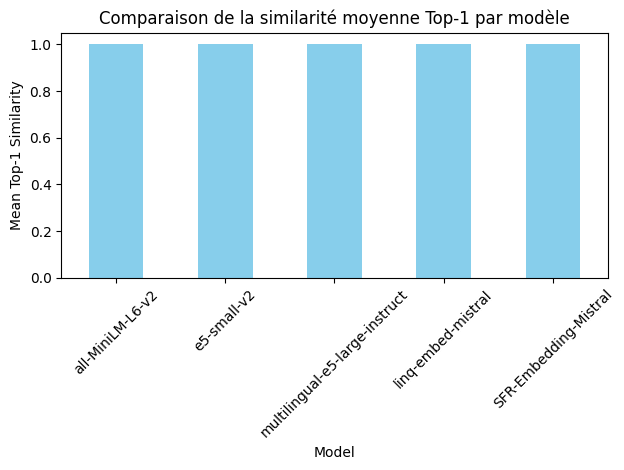

In [11]:
plt.figure(figsize=(10, 5))
df_summary.plot(x="Model", y="Mean Top-1 Similarity", kind="bar", legend=False, color="skyblue")
plt.ylabel("Mean Top-1 Similarity")
plt.title("Comparaison de la similarité moyenne Top-1 par modèle")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

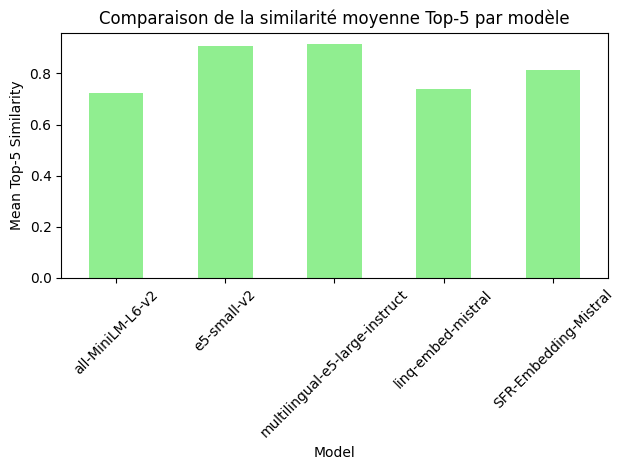

In [12]:
# Barplot de similarité Top-5
plt.figure(figsize=(10, 5))
df_summary.plot(x="Model", y="Mean Top-5 Similarity", kind="bar", legend=False, color="lightgreen")
plt.ylabel("Mean Top-5 Similarity")
plt.title("Comparaison de la similarité moyenne Top-5 par modèle")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<Figure size 1000x500 with 0 Axes>

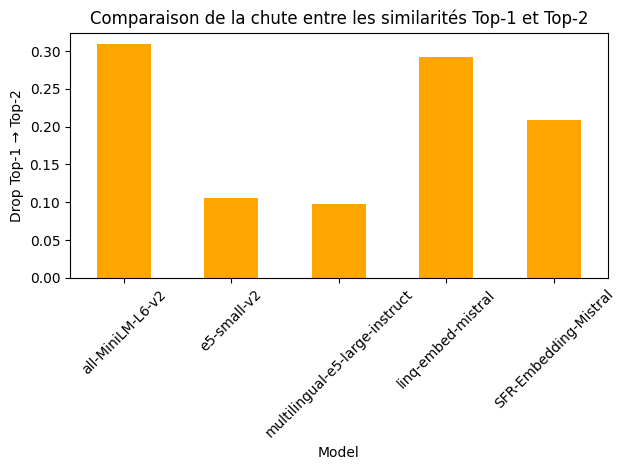

In [13]:
# Drop Top-1 -> Top-2
plt.figure(figsize=(10, 5))
df_summary.plot(x="Model", y="Mean Drop Top-1 to Top-2", kind="bar", legend=False, color="orange")
plt.ylabel("Drop Top-1 → Top-2")
plt.title("Comparaison de la chute entre les similarités Top-1 et Top-2")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<Figure size 1000x500 with 0 Axes>

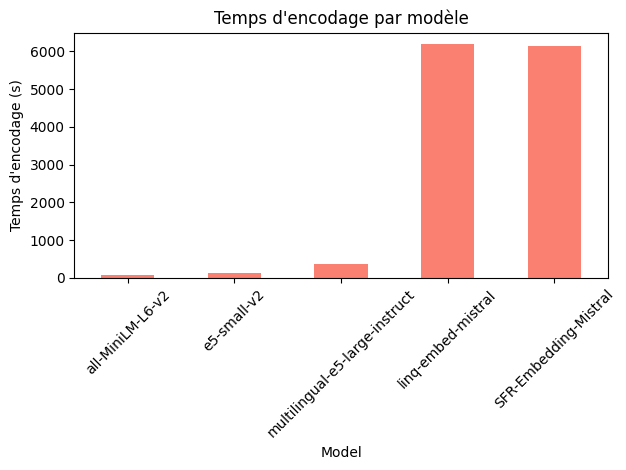

In [14]:
plt.figure(figsize=(10, 5))
df_summary.plot(x="Model", y="Doc Encoding Time (s)", kind="bar", legend=False, color="salmon")
plt.ylabel("Temps d'encodage (s)")
plt.title("Temps d'encodage par modèle")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [2]:
os.listdir("embedding_benchmark_results")

['all-MiniLM-L6-v2',
 'e5-small-v2',
 'multilingual-e5-large-instruct',
 'linq-embed-mistral',
 'SFR-Embedding-Mistral']

In [3]:
doc_embeddings_all_MiniLM = np.load("embedding_benchmark_results/all-MiniLM-L6-v2/embeddings.npy")

In [4]:
n_clusters = 10

In [5]:
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(doc_embeddings_all_MiniLM)

In [21]:
sample_embeddings, sample_labels = resample(doc_embeddings_all_MiniLM, labels, n_samples=10000, random_state=42)

In [22]:
score = silhouette_score(sample_embeddings, sample_labels)
score

0.0103007145

In [27]:
score = davies_bouldin_score(doc_embeddings_all_MiniLM, labels)
score

6.128916755250466

In [29]:
score = calinski_harabasz_score(doc_embeddings_all_MiniLM, labels)
score

10286.343983308649

In [30]:
doc_embeddings_e5_small = np.load("embedding_benchmark_results/e5-small-v2/embeddings.npy")

In [31]:
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(doc_embeddings_e5_small)

In [32]:
sample_embeddings, sample_labels = resample(doc_embeddings_e5_small, labels, n_samples=10000, random_state=42)
score = silhouette_score(sample_embeddings, sample_labels)
score

-0.0014443806

In [33]:
score = davies_bouldin_score(doc_embeddings_e5_small, labels)
score

6.081790974300675

In [34]:
score = calinski_harabasz_score(doc_embeddings_e5_small, labels)
score

7627.8938743487115

In [36]:
doc_embeddings_e5_large = np.load("embedding_benchmark_results/multilingual-e5-large-instruct/embeddings.npy")

In [37]:
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(doc_embeddings_e5_large)

In [38]:
sample_embeddings, sample_labels = resample(doc_embeddings_e5_large, labels, n_samples=10000, random_state=42)
score = silhouette_score(sample_embeddings, sample_labels)
score

0.014327599

In [39]:
score = davies_bouldin_score(doc_embeddings_e5_large, labels)
score

5.661709733784582

In [40]:
score = calinski_harabasz_score(doc_embeddings_e5_large, labels)
score

10430.90281341541

In [2]:
doc_embeddings_linq = np.load("embedding_benchmark_results/linq-embed-mistral/embeddings.npy")

In [5]:
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(doc_embeddings_linq)

In [6]:
sample_embeddings, sample_labels = resample(doc_embeddings_linq, labels, n_samples=10000, random_state=42)
score = silhouette_score(sample_embeddings, sample_labels)
score

0.010003128

In [7]:
score = davies_bouldin_score(doc_embeddings_linq, labels)
score

6.689930828206961

In [8]:
score = calinski_harabasz_score(doc_embeddings_linq, labels)
score

9065.885176055963

In [9]:
doc_embeddings_sfr = np.load("embedding_benchmark_results/SFR-Embedding-Mistral/embeddings.npy")

In [10]:
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(doc_embeddings_sfr)

In [11]:
sample_embeddings, sample_labels = resample(doc_embeddings_sfr, labels, n_samples=10000, random_state=42)
score = silhouette_score(sample_embeddings, sample_labels)
score

0.010611326

In [12]:
score = davies_bouldin_score(doc_embeddings_sfr, labels)
score

6.158318372262215

In [13]:
score = calinski_harabasz_score(doc_embeddings_sfr, labels)
score

7032.896304679521

In [14]:
len(doc_embeddings_sfr)

688992